<a href="https://colab.research.google.com/github/AylinSahin/MagicBathyNet/blob/main/debug_first_bathymetry_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Debug-first bathymetry pipeline: Depth Anything V2 / MagicBathyNet

Bu notebook mevcut pipeline'ı **önce teşhis etmek**, sonra temiz bir **fine-tuning + GeoTIFF inference + GPR doğrulama** akışı kurmak için hazırlanmıştır.

Ana prensipler:
- RGB preprocessing tek fonksiyondan yönetilir.
- Depth label convention açıkça test edilir.
- Optimizer'ın gerçekten eğitilen modele bağlı olduğu doğrulanır.
- Prediction ham/ters/kalibre edilmiş seçeneklerle GPR üzerinde karşılaştırılır.
- Normalized-space ve meter-space metrikleri kesin olarak ayrılır.


In [ ]:
# ============================================================
# 01 - Imports
# ============================================================
import os, re, json, ast, random, math, gc, warnings
from pathlib import Path

import numpy as np
import pandas as pd

import rasterio
from rasterio.warp import transform as rio_transform
from rasterio.transform import rowcol

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


torch: 2.11.0+cu128
cuda available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -n /content/drive/MyDrive/Colab_Notebooks/depth_v2_basic_normalized_output.tif /content/
!cp -n /content/drive/MyDrive/Colab_Notebooks/depth_v1_normalized_output.tif /content/
!cp -n /content/drive/MyDrive/Colab_Notebooks/depth_v2_indoor_hypersim_normalized_output.tif /content/
!cp -n /content/drive/MyDrive/Colab_Notebooks/depth_v2_outdoor_vkitti_normalized_output.tif /content/

!cp -n /content/drive/MyDrive/unet_aerial_pl /content/
!cp -n /content/drive/MyDrive/bathymetry_aerial_pl /content/

In [ ]:
# ============================================================
# 02 - Path config
# ============================================================
ROOT = Path("/content/drive/MyDrive/MagicBathyNet")
FOLDER = ROOT / "puck_lagoon"

DATA_FOLDER  = FOLDER / "img" / "aerial" / "img_{}.tif"
LABEL_FOLDER = FOLDER / "depth" / "aerial" / "depth_{}.tif"
SPLIT_PATH   = FOLDER / "aerial_split_bathymetry.txt"
NORM_RGB_PATH = FOLDER / "norm_param_aerial.npy"

ORTHO_TIF = Path("/content/lake_calculation_area.tif")
GPR_XLSX  = Path("/content/GPR_Depth_Analysis.xlsx")

CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT = CKPT_DIR / "unet_bathy_best.pt"

OUT_DIR = ROOT / "debug_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# MagicBathyNet convention: Puck Lagoon için referans notebook'ta -11 kullanılıyor.
norm_param_depth = -11.0
depth_scale_m = abs(norm_param_depth)

WINDOW_SIZE = (720, 720)
BATCH_SIZE = 1
SEED = 42

print("DEVICE:", DEVICE)
print("depth_scale_m:", depth_scale_m)


DEVICE: cuda
depth_scale_m: 11.0


In [ ]:
# ============================================================
# 03 - Seed
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)


In [ ]:
# ============================================================
# 04 - GPR okuma ve özet
# ============================================================
def read_gpr_excel(path):
    df = pd.read_excel(path)
    required = ["Latitude", "Longitude", "Depth [m]"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"GPR dosyasında eksik kolon(lar): {missing}. Mevcut kolonlar: {list(df.columns)}")
    df = df.copy()
    df = df.dropna(subset=required)
    df["Latitude"] = df["Latitude"].astype(float)
    df["Longitude"] = df["Longitude"].astype(float)
    df["Depth [m]"] = df["Depth [m]"].astype(float)
    return df

gpr = read_gpr_excel(GPR_XLSX)
display(gpr.head())
print(gpr[["Latitude", "Longitude", "Depth [m]"]].describe())


,Trace,Latitude,Longitude,Depth [m]
0,107,-67.828755,-67.226238,0.6275
1,95,-67.828787,-67.226274,0.3922
2,73,-67.828838,-67.226298,0.3660
3,47,-67.828889,-67.226299,0.3660
4,25,-67.828920,-67.226297,0.3660


         Latitude   Longitude   Depth [m]
count  112.000000  112.000000  112.000000
mean   -67.828320  -67.225914    1.276027
std      0.000385    0.000302    0.701061
min    -67.828969  -67.226370    0.313800
25%    -67.828688  -67.226219    0.653700
50%    -67.828307  -67.225915    1.150400
75%    -67.827945  -67.225743    1.836750
max    -67.827653  -67.225227    2.745400


In [ ]:
# ============================================================
# 05 - Split okuma + train/test leakage kontrolü
# ============================================================
def extract_list_after(text, tag):
    i = text.find(tag)
    if i < 0:
        raise ValueError(f"Tag bulunamadı: {tag}")
    sub = text[i:]
    list_str = sub[sub.find("["):sub.find("]")+1]
    return [int(x) for x in ast.literal_eval(list_str)]

def read_split_file(split_path):
    text = Path(split_path).read_text()
    train_ids = extract_list_after(text, "train sample:")
    test_ids  = extract_list_after(text, "test sample:")
    return train_ids, test_ids

train_ids, test_ids = read_split_file(SPLIT_PATH)

overlap_ids = sorted(set(train_ids).intersection(set(test_ids)))
print("Train count:", len(train_ids))
print("Test count :", len(test_ids))
print("ID overlap :", overlap_ids if overlap_ids else "No exact ID overlap")

print("\nTrain IDs:", train_ids)
print("\nTest IDs :", test_ids)

if overlap_ids:
    raise RuntimeError("Kritik leakage: aynı ID train ve test içinde var.")

print("""
Not:
Exact ID çakışması olmaması yeterli değildir. Patch tabanlı split varsa aynı büyük sahneden
gelen komşu patch'ler train/test'e karışabilir. Tek göl/tek ortofoto uygulamasında
random patch split yerine spatial split veya spatial block cross-validation önerilir.
""")


Train count: 1575
Test count : 396
ID overlap : No exact ID overlap

Train IDs: [290, 2497, 893, 2261, 2918, 2683, 1131, 1296, 2355, 2627, 3278, 2179, 3153, 552, 1802, 88, 778, 1385, 1157, 3234, 2185, 1657, 689, 879, 1132, 48, 1974, 3276, 1219, 2782, 787, 2170, 2413, 6, 836, 2964, 2768, 1475, 842, 152, 1378, 2209, 679, 2572, 1115, 512, 521, 1148, 400, 898, 866, 404, 625, 1073, 1067, 696, 2879, 2409, 2619, 2285, 2658, 2383, 1020, 2521, 2416, 508, 1819, 2127, 1127, 881, 416, 3193, 613, 1882, 1072, 1826, 1049, 477, 1470, 783, 420, 2335, 1301, 474, 686, 1537, 604, 3048, 1311, 1547, 1472, 2055, 2119, 1294, 1476, 1549, 1291, 1199, 682, 2203, 2550, 627, 3051, 2338, 2424, 933, 2284, 3219, 844, 1716, 265, 1468, 1576, 1956, 2696, 3021, 2319, 1122, 1139, 462, 1313, 2276, 1130, 1900, 1958, 1469, 2828, 728, 2029, 2578, 2198, 1892, 359, 1876, 2388, 1323, 3103, 494, 399, 688, 918, 1631, 717, 1572, 3077, 2821, 1805, 850, 730, 3154, 2181, 3078, 965, 144, 1058, 799, 2981, 2317, 2173, 2470, 386, 771, 17,

In [ ]:
# ============================================================
# 06 - Ortak RGB preprocessing fonksiyonu
# ============================================================
norm_param = np.load(NORM_RGB_PATH).astype(np.float32)
print("norm_param shape:", norm_param.shape)
print(norm_param)

def _to_hwc_rgb(arr, source="unknown"):
    # Rasterio: (C,H,W), skimage: (H,W,C) olabilir.
    # Alpha band varsa RGB'ye dahil edilmez.
    arr = np.asarray(arr)
    if arr.ndim != 3:
        raise ValueError(f"{source}: RGB/RGBA array 3D olmalı. shape={arr.shape}")

    # C,H,W -> H,W,C
    if arr.shape[0] in [3,4] and arr.shape[-1] not in [3,4]:
        arr = np.transpose(arr, (1,2,0))

    if arr.shape[-1] < 3:
        raise ValueError(f"{source}: En az 3 band gerekir. shape={arr.shape}")

    rgb = arr[..., :3]
    return rgb

def preprocess_rgb(arr, norm_param=None, clip=True, return_mask=False, source="unknown"):
    """
    Eğitim ve inference için TEK ortak RGB preprocessing.
    - Alpha band input kanalı olarak kullanılmaz.
    - Rasterio band sırası RGB kabul edilir: band1=R, band2=G, band3=B.
    - norm_param verilirse MagicBathyNet tarzı min-max uygulanır.
    """
    arr = np.asarray(arr)
    valid_mask = None

    # Alpha mask üret
    if arr.ndim == 3:
        if arr.shape[0] >= 4 and arr.shape[-1] not in [3,4]:
            alpha = arr[3]
            valid_mask = alpha > 0
        elif arr.shape[-1] >= 4:
            alpha = arr[..., 3]
            valid_mask = alpha > 0

    rgb = _to_hwc_rgb(arr, source=source).astype(np.float32)

    if valid_mask is None:
        valid_mask = np.ones(rgb.shape[:2], dtype=bool)

    if norm_param is not None:
        np_norm = np.asarray(norm_param, dtype=np.float32)

        if np_norm.shape == (2, 3):
            mn = np_norm[0].reshape(1,1,3)
            mx = np_norm[1].reshape(1,1,3)
        elif np_norm.shape == (3, 2):
            mn = np_norm[:,0].reshape(1,1,3)
            mx = np_norm[:,1].reshape(1,1,3)
        else:
            raise ValueError(f"norm_param shape beklenmiyor: {np_norm.shape}")

        rgb = (rgb - mn) / (mx - mn + 1e-8)
    else:
        # Fallback sadece debug amaçlıdır; training ile aynı olmayabilir.
        mx = np.nanmax(rgb[valid_mask]) if np.any(valid_mask) else np.nanmax(rgb)
        if mx > 1.5:
            if mx <= 255:
                rgb = rgb / 255.0
            elif mx <= 65535:
                rgb = rgb / 65535.0
            else:
                rgb = rgb / mx

    if clip:
        rgb = np.clip(rgb, 0.0, 1.0)

    rgb = rgb.astype(np.float32)

    if return_mask:
        return rgb, valid_mask
    return rgb

def hwc_to_tensor(rgb):
    return torch.from_numpy(rgb).permute(2,0,1).float()

print("preprocess_rgb ready.")


norm_param shape: (2, 3)
[[  0.   0.   0.]
 [255. 255. 255.]]
preprocess_rgb ready.


In [ ]:
# ============================================================
# 07 - Depth normalization / inverse scaling
# ============================================================
def depth_to_label(depth_arr_m_or_signed, norm_param_depth=-11.0):
    """
    MagicBathyNet referansındaki convention:
        label = depth_tif / norm_param_depth

    Eğer depth_tif negatif bathymetric elevation ise:
        -2 m / -11 = +0.1818 normalize label.
    Bu durumda derinlik arttıkça label artar.
    """
    return np.asarray(depth_arr_m_or_signed, dtype=np.float32) / float(norm_param_depth)

def label_to_depth_m(label, norm_param_depth=-11.0, positive_depth=True):
    """
    Normalize label'i metreye çevirir.
    positive_depth=True: çıktı pozitif su derinliği metre olarak döner.
    """
    signed = np.asarray(label, dtype=np.float32) * float(norm_param_depth)
    if positive_depth:
        return -signed
    return signed

def normalize_01(arr, mask=None):
    arr = np.asarray(arr, dtype=np.float32)
    if mask is None:
        mask = np.isfinite(arr)
    vals = arr[mask]
    mn, mx = np.nanmin(vals), np.nanmax(vals)
    out = (arr - mn) / (mx - mn + 1e-8)
    return out.astype(np.float32), float(mn), float(mx)

def inverse_normalized(pred_norm):
    return 1.0 - np.asarray(pred_norm, dtype=np.float32)

def inverse_dynamic(pred):
    pred = np.asarray(pred, dtype=np.float32)
    return np.nanmax(pred) - pred

print("Depth conversion ready. depth_scale_m =", depth_scale_m)


Depth conversion ready. depth_scale_m = 11.0


In [ ]:
# ============================================================
# 08 - Dataset class: ortak preprocessing kullanan temiz sürüm
# ============================================================
from skimage import io as skio

class BathyPatchDataset(Dataset):
    def __init__(self, ids, data_template, label_template, norm_param, norm_param_depth,
                 window_size=(720,720), length=10000, augmentation=True, cache=False):
        self.ids = list(ids)
        self.data_template = str(data_template)
        self.label_template = str(label_template)
        self.norm_param = norm_param
        self.norm_param_depth = norm_param_depth
        self.window_size = window_size
        self.length = length
        self.augmentation = augmentation
        self.cache = cache
        self._data_cache = {}
        self._label_cache = {}

        for id_ in self.ids:
            if not Path(self.data_template.format(id_)).is_file():
                raise FileNotFoundError(self.data_template.format(id_))
            if not Path(self.label_template.format(id_)).is_file():
                raise FileNotFoundError(self.label_template.format(id_))

    def __len__(self):
        return self.length

    @staticmethod
    def augment(x, y):
        # x: C,H,W, y: H,W
        if random.random() < 0.5:
            x = x[:, ::-1, :]
            y = y[::-1, :]
        if random.random() < 0.5:
            x = x[:, :, ::-1]
            y = y[:, ::-1]
        return np.copy(x), np.copy(y)

    def _read_pair(self, idx):
        id_ = self.ids[idx]
        if idx in self._data_cache:
            return self._data_cache[idx], self._label_cache[idx]

        img = skio.imread(self.data_template.format(id_))
        rgb = preprocess_rgb(img, self.norm_param, source=f"train img {id_}")
        x = np.transpose(rgb, (2,0,1)).astype(np.float32)

        depth = skio.imread(self.label_template.format(id_)).astype(np.float32)
        y = depth_to_label(depth, self.norm_param_depth).astype(np.float32)

        if self.cache:
            self._data_cache[idx] = x
            self._label_cache[idx] = y
        return x, y

    def __getitem__(self, i):
        idx = random.randint(0, len(self.ids)-1)
        x, y = self._read_pair(idx)

        wh, ww = self.window_size
        H, W = y.shape
        if H < wh or W < ww:
            raise ValueError(f"Patch window {self.window_size} image'den büyük: label shape={y.shape}")

        r0 = random.randint(0, H - wh)
        c0 = random.randint(0, W - ww)

        xp = x[:, r0:r0+wh, c0:c0+ww]
        yp = y[r0:r0+wh, c0:c0+ww]

        if self.augmentation:
            xp, yp = self.augment(xp, yp)

        return torch.from_numpy(xp), torch.from_numpy(yp).unsqueeze(0)

train_data = BathyPatchDataset(train_ids, DATA_FOLDER, LABEL_FOLDER, norm_param, norm_param_depth,
                               window_size=WINDOW_SIZE, augmentation=True, cache=False)
test_data = BathyPatchDataset(test_ids, DATA_FOLDER, LABEL_FOLDER, norm_param, norm_param_depth,
                              window_size=WINDOW_SIZE, augmentation=False, cache=False)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x, y = next(iter(test_loader))
print("x:", x.shape, x.dtype, float(x.min()), float(x.max()))
print("y label:", y.shape, y.dtype, float(y.min()), float(y.max()))
print("y meter:", float(label_to_depth_m(y.numpy(), norm_param_depth).min()), float(label_to_depth_m(y.numpy(), norm_param_depth).max()))


x: torch.Size([1, 3, 720, 720]) torch.float32 0.09803921729326248 0.7058823704719543
y label: torch.Size([1, 1, 720, 720]) torch.float32 0.08410363644361496 0.3314814865589142
y meter: 0.9251400232315063 3.646296262741089


In [ ]:
# ============================================================
# 09 - Model + optimizer bağlantı testi
# ============================================================
import sys
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from bathymetry.magicbathy_unet import UNet_bathy

bathy_model = UNet_bathy(in_channels=3, out_channels=1).to(DEVICE)

# KRİTİK: optimizer kesinlikle bathy_model.parameters() almalı.
optimizer = optim.Adam(bathy_model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

def assert_optimizer_tracks_model(optimizer, model):
    opt_param_ids = {id(p) for group in optimizer.param_groups for p in group["params"]}
    model_param_ids = {id(p) for p in model.parameters()}
    missing = model_param_ids - opt_param_ids
    extra = opt_param_ids - model_param_ids
    print("Model param count    :", len(model_param_ids))
    print("Optimizer param count:", len(opt_param_ids))
    print("Missing in optimizer :", len(missing))
    print("Extra in optimizer   :", len(extra))
    assert len(missing) == 0, "KRİTİK: optimizer model parametrelerinin hepsini takip etmiyor."
    assert len(extra) == 0, "UYARI/KRİTİK: optimizer başka bir modelin parametrelerini içeriyor."
    print("✅ Optimizer doğru modele bağlı.")

assert_optimizer_tracks_model(optimizer, bathy_model)


Model param count    : 36
Optimizer param count: 36
Missing in optimizer : 0
Extra in optimizer   : 0
✅ Optimizer doğru modele bağlı.


In [ ]:
def load_checkpoint(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)

    missing, unexpected = model.load_state_dict(
        ckpt["model_state"],
        strict=False
    )

    model.to(device)
    model.eval()

    print("Loaded checkpoint:", ckpt_path)
    print("Epoch:", ckpt.get("epoch"))
    print("Val loss normalized:", ckpt.get("val_loss_normalized", ckpt.get("val_loss")))
    print("Train loss normalized:", ckpt.get("train_loss_normalized"))
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    return ckpt

ckpt = load_checkpoint(bathy_model, BEST_CKPT, DEVICE)

Loaded checkpoint: /content/drive/MyDrive/MagicBathyNet/checkpoints/unet_bathy_best.pt
Epoch: 2
Val loss normalized: 0.007902076226753707
Train loss normalized: 0.008024284787534452
Missing keys: []
Unexpected keys: []


In [ ]:
# ============================================================
# 10 - Training loop
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device, max_batches=None):
    model.train()
    losses = []
    for i, (x, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        x = x.to(device).float()
        y = y.to(device).float()

        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        if pred.shape != y.shape:
            raise RuntimeError(f"pred/y shape mismatch: pred={pred.shape}, y={y.shape}")
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else np.nan

@torch.no_grad()
def evaluate_normalized(model, loader, criterion, device, max_batches=None):
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        x = x.to(device).float()
        y = y.to(device).float()
        pred = model(x)
        losses.append(float(criterion(pred, y).item()))
    return float(np.mean(losses)) if losses else np.nan

EPOCHS = 5
best_val = float("inf")

for epoch in range(1, EPOCHS+1):
    tr = train_one_epoch(bathy_model, train_loader, optimizer, criterion, DEVICE, max_batches=None)
    va = evaluate_normalized(bathy_model, test_loader, criterion, DEVICE, max_batches=500)
    print(f"Epoch {epoch:03d} | train_loss_normalized={tr:.6f} | val_loss_normalized={va:.6f}")

    if va < best_val:
        best_val = va
        torch.save({
            "epoch": epoch,
            "model_state": bathy_model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss_normalized": va,
            "train_loss_normalized": tr,
            "norm_param_depth": norm_param_depth,
        }, BEST_CKPT)
        print("✅ saved:", BEST_CKPT)


Epoch 001 | train_loss_normalized=0.008999 | val_loss_normalized=0.009936
✅ saved: /content/drive/MyDrive/MagicBathyNet/checkpoints/unet_bathy_best.pt
Epoch 002 | train_loss_normalized=0.008024 | val_loss_normalized=0.007902
✅ saved: /content/drive/MyDrive/MagicBathyNet/checkpoints/unet_bathy_best.pt
Epoch 003 | train_loss_normalized=0.007784 | val_loss_normalized=0.008195
Epoch 004 | train_loss_normalized=0.007465 | val_loss_normalized=0.009245
Epoch 005 | train_loss_normalized=0.007345 | val_loss_normalized=0.008467


In [ ]:
# ============================================================
# 11 - Checkpoint yükleme testi
# ============================================================
def load_checkpoint(model, path, device):
    ckpt = torch.load(path, map_location="cpu")
    missing, unexpected = model.load_state_dict(ckpt["model_state"], strict=False)
    model.to(device).eval()
    print("Loaded:", path)
    print("epoch:", ckpt.get("epoch"))
    print("val_loss_normalized:", ckpt.get("val_loss_normalized", ckpt.get("val_loss")))
    print("missing keys:", missing)
    print("unexpected keys:", unexpected)
    return ckpt

if BEST_CKPT.exists():
    ckpt = load_checkpoint(bathy_model, BEST_CKPT, DEVICE)
else:
    print("Checkpoint bulunmadı; önce training cell'i çalıştır.")


Loaded: /content/drive/MyDrive/MagicBathyNet/checkpoints/unet_bathy_best.pt
epoch: 2
val_loss_normalized: 0.007902076226753707
missing keys: []
unexpected keys: []


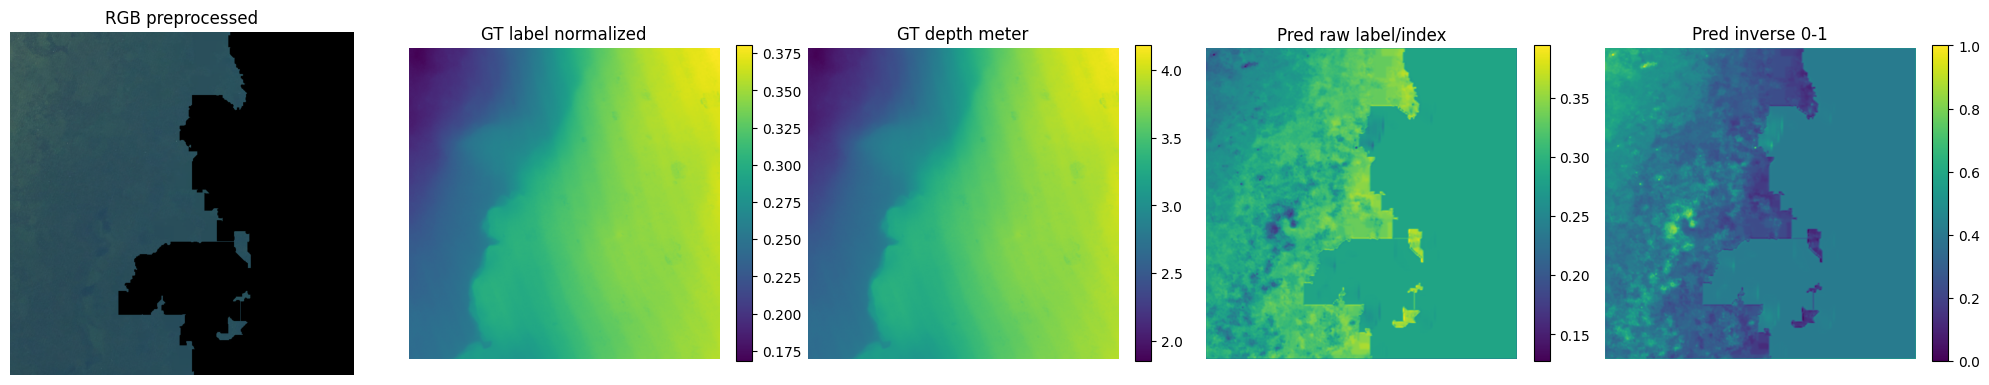

In [ ]:
# ============================================================
# 12 - Sample label + prediction + inverse görselleştirme
# ============================================================
@torch.no_grad()
def show_sample_prediction(model, loader, device, norm_param_depth=-11.0):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device).float()
    y = y.to(device).float()
    pred = model(x)

    rgb = x[0].detach().cpu().numpy().transpose(1,2,0)
    label = y[0,0].detach().cpu().numpy()
    pred_raw = pred[0,0].detach().cpu().numpy()

    label_m = label_to_depth_m(label, norm_param_depth)
    pred_raw_m = label_to_depth_m(pred_raw, norm_param_depth)

    pred01, _, _ = normalize_01(pred_raw)
    pred_inv01 = 1 - pred01

    fig, axes = plt.subplots(1,5, figsize=(20,4))
    axes[0].imshow(np.clip(rgb,0,1)); axes[0].set_title("RGB preprocessed")
    im1 = axes[1].imshow(label); axes[1].set_title("GT label normalized"); plt.colorbar(im1, ax=axes[1], fraction=0.046)
    im2 = axes[2].imshow(label_m); axes[2].set_title("GT depth meter"); plt.colorbar(im2, ax=axes[2], fraction=0.046)
    im3 = axes[3].imshow(pred_raw); axes[3].set_title("Pred raw label/index"); plt.colorbar(im3, ax=axes[3], fraction=0.046)
    im4 = axes[4].imshow(pred_inv01); axes[4].set_title("Pred inverse 0-1"); plt.colorbar(im4, ax=axes[4], fraction=0.046)
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_prediction(bathy_model, test_loader, DEVICE, norm_param_depth)


In [ ]:
# ============================================================
# 13 - GeoTIFF tile-based inference
# ============================================================
def make_weight(h, w, eps=1e-6):
    y = np.linspace(0, np.pi, h, dtype=np.float32)
    x = np.linspace(0, np.pi, w, dtype=np.float32)
    w2 = np.sin(y)[:,None] * np.sin(x)[None,:]
    return np.maximum(w2, eps).astype(np.float32)

@torch.no_grad()
def infer_geotiff(model, in_tif, out_tif_raw, norm_param, device,
                  tile=720, overlap=160, nodata=0.0):
    assert tile > overlap
    model.eval().to(device)

    with rasterio.open(in_tif) as src:
        profile = src.profile.copy()
        data = src.read()
        H, W = src.height, src.width
        crs = src.crs
        transform = src.transform

    rgb, valid_mask = preprocess_rgb(data, norm_param=norm_param, return_mask=True, source=str(in_tif))

    pred_accum = np.zeros((H,W), dtype=np.float32)
    w_accum = np.zeros((H,W), dtype=np.float32)

    step = tile - overlap
    ys = list(range(0, max(H - tile + 1, 1), step))
    xs = list(range(0, max(W - tile + 1, 1), step))
    if len(ys) == 0 or ys[-1] != max(0, H-tile):
        ys.append(max(0, H-tile))
    if len(xs) == 0 or xs[-1] != max(0, W-tile):
        xs.append(max(0, W-tile))
    ys = sorted(set(ys))
    xs = sorted(set(xs))

    weight_full = make_weight(tile, tile)

    for y0 in ys:
        for x0 in xs:
            y1 = min(y0 + tile, H)
            x1 = min(x0 + tile, W)
            patch_rgb = rgb[y0:y1, x0:x1, :]
            patch_mask = valid_mask[y0:y1, x0:x1]

            if not np.any(patch_mask):
                continue

            ph, pw = patch_rgb.shape[:2]
            pad_h = tile - ph
            pad_w = tile - pw
            if pad_h > 0 or pad_w > 0:
                patch_rgb_pad = np.pad(patch_rgb, ((0,pad_h),(0,pad_w),(0,0)), mode="reflect")
                patch_mask_pad = np.pad(patch_mask, ((0,pad_h),(0,pad_w)), mode="constant", constant_values=False)
            else:
                patch_rgb_pad = patch_rgb

            inp = torch.from_numpy(patch_rgb_pad).permute(2,0,1).unsqueeze(0).to(device).float()
            pred = model(inp)
            pred = pred[0,0].detach().cpu().numpy().astype(np.float32)
            pred = pred[:ph, :pw]

            w = weight_full[:ph, :pw].copy()
            w[~patch_mask] = 0

            pred_accum[y0:y1, x0:x1] += pred * w
            w_accum[y0:y1, x0:x1] += w

    out = np.full((H,W), nodata, dtype=np.float32)
    ok = w_accum > 0
    out[ok] = pred_accum[ok] / w_accum[ok]

    profile.update(driver="GTiff", count=1, dtype="float32", nodata=nodata, compress="lzw")
    Path(out_tif_raw).parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_tif_raw, "w", **profile) as dst:
        dst.write(out.astype(np.float32), 1)

    print("Saved raw prediction GeoTIFF:", out_tif_raw)
    print("CRS preserved:", crs)
    print("Transform preserved:", transform)
    return out_tif_raw

RAW_TIF = OUT_DIR / "prediction_raw_normalized_index.tif"
infer_geotiff(bathy_model, ORTHO_TIF, RAW_TIF, norm_param, DEVICE, tile=720, overlap=160)


Saved raw prediction GeoTIFF: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_raw_normalized_index.tif
CRS preserved: EPSG:32719
Transform preserved: | 0.04, 0.00, 574667.78|
| 0.00,-0.04, 2475298.14|
| 0.00, 0.00, 1.00|


PosixPath('/content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_raw_normalized_index.tif')

In [ ]:
# ============================================================
# 14 - GPR sampling
# ============================================================
def sample_raster_at_gpr(raster_path, gpr_df, lon_col="Longitude", lat_col="Latitude", nodata_values=(0.0,)):
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(np.float32)
        raster_crs = src.crs
        src_nodata = src.nodata
        H, W = src.height, src.width

        xs = gpr_df[lon_col].to_numpy()
        ys = gpr_df[lat_col].to_numpy()

        if raster_crs is None:
            raise ValueError("Raster CRS yok; GPR örneklemesi güvenilir yapılamaz.")

        if str(raster_crs).upper() not in ["EPSG:4326", "OGC:CRS84"]:
            tx, ty = rio_transform("EPSG:4326", raster_crs, xs.tolist(), ys.tolist())
        else:
            tx, ty = xs, ys

        rows, cols = rowcol(src.transform, tx, ty)
        rows = np.asarray(rows)
        cols = np.asarray(cols)

    out = gpr_df.copy()
    out["row"] = rows
    out["col"] = cols
    out["inside_raster"] = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)

    sampled = np.full(len(out), np.nan, dtype=np.float32)
    inside_idx = np.where(out["inside_raster"].to_numpy())[0]
    sampled[inside_idx] = arr[rows[inside_idx], cols[inside_idx]]

    invalid = ~np.isfinite(sampled)
    if src_nodata is not None:
        invalid |= sampled == src_nodata
    for nd in nodata_values:
        invalid |= sampled == nd

    out["pred_sample"] = sampled
    out["valid_sample"] = out["inside_raster"] & (~invalid)

    print("Total GPR:", len(out))
    print("Outside raster:", int((~out["inside_raster"]).sum()))
    print("Invalid/nodata sample:", int((out["inside_raster"] & ~out["valid_sample"]).sum()))
    print("Valid samples:", int(out["valid_sample"].sum()))
    return out

sampled_raw = sample_raster_at_gpr(RAW_TIF, gpr)
display(sampled_raw.head())


Total GPR: 112
Outside raster: 0
Invalid/nodata sample: 3
Valid samples: 109


,Trace,Latitude,Longitude,Depth [m],row,col,inside_raster,pred_sample,valid_sample
0,107,-67.828755,-67.226238,0.6275,3603,590,True,0.057872,True
1,95,-67.828787,-67.226274,0.3922,3694,550,True,0.053601,True
2,73,-67.828838,-67.226298,0.3660,3837,519,True,0.048562,True
3,47,-67.828889,-67.226299,0.3660,3984,514,True,0.000000,False
4,25,-67.828920,-67.226297,0.3660,4071,514,True,0.000000,False


In [ ]:
# ============================================================
# Map formatting helpers: W/S coordinate labels, north arrow, scale bar
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pyproj import Transformer
from matplotlib.patches import Rectangle, Circle
from mpl_toolkits.axes_grid1 import make_axes_locatable

def format_lon_w(lon, decimals=4):
    return f"{abs(lon):.{decimals}f}°W" if lon < 0 else f"{abs(lon):.{decimals}f}°E"

def format_lat_s(lat, decimals=4):
    return f"{abs(lat):.{decimals}f}°S" if lat < 0 else f"{abs(lat):.{decimals}f}°N"

def padded_bounds(bounds, pad_frac=0.06):
    width = bounds.right - bounds.left
    height = bounds.top - bounds.bottom

    return {
        "left": bounds.left - width * pad_frac,
        "right": bounds.right + width * pad_frac,
        "bottom": bounds.bottom - height * pad_frac,
        "top": bounds.top + height * pad_frac,
    }

def set_sw_ticks_with_padding(ax, raster_crs, plot_bounds, nx=3, ny=4, decimals=4):
    transformer = Transformer.from_crs(raster_crs, "EPSG:4326", always_xy=True)

    xticks = np.linspace(plot_bounds["left"], plot_bounds["right"], nx)
    yticks = np.linspace(plot_bounds["bottom"], plot_bounds["top"], ny)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    xlabels = []
    y_mid = 0.5 * (plot_bounds["bottom"] + plot_bounds["top"])
    for x in xticks:
        lon, lat = transformer.transform(x, y_mid)
        xlabels.append(format_lon_w(lon, decimals))

    ylabels = []
    x_mid = 0.5 * (plot_bounds["left"] + plot_bounds["right"])
    for y in yticks:
        lon, lat = transformer.transform(x_mid, y)
        ylabels.append(format_lat_s(lat, decimals))

    ax.set_xticklabels(xlabels, fontsize=11)
    ax.set_yticklabels(ylabels, fontsize=11)

    ax.set_xlabel("")
    ax.set_ylabel("")

def add_north_arrow_clean(ax, x=0.88, y=0.88, size=0.065):
    circ = Circle(
        (x, y),
        radius=size,
        transform=ax.transAxes,
        fill=False,
        linewidth=1.4,
        edgecolor="black",
        alpha=0.75,
        zorder=20
    )
    ax.add_patch(circ)

    ax.plot([x, x], [y - size * 0.68, y + size * 0.68],
            transform=ax.transAxes, color="black", lw=1.3, zorder=21)
    ax.plot([x - size * 0.68, x + size * 0.68], [y, y],
            transform=ax.transAxes, color="black", lw=1.3, zorder=21)

    ax.annotate(
        "",
        xy=(x, y + size * 0.78),
        xytext=(x, y + size * 0.12),
        xycoords=ax.transAxes,
        arrowprops=dict(arrowstyle="-|>", lw=1.3, color="black"),
        zorder=22
    )

    ax.text(x, y + size * 1.06, "N", transform=ax.transAxes,
            ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(x + size * 1.05, y, "E", transform=ax.transAxes,
            ha="center", va="center", fontsize=10)
    ax.text(x, y - size * 1.05, "S", transform=ax.transAxes,
            ha="center", va="center", fontsize=10)
    ax.text(x - size * 1.05, y, "W", transform=ax.transAxes,
            ha="center", va="center", fontsize=10)

def add_scale_bar_clean(ax, plot_bounds, length_m=20, location=(0.10, 0.07)):
    x0_frac, y0_frac = location

    width = plot_bounds["right"] - plot_bounds["left"]
    height = plot_bounds["top"] - plot_bounds["bottom"]

    x0 = plot_bounds["left"] + x0_frac * width
    y0 = plot_bounds["bottom"] + y0_frac * height

    bar_h = height * 0.012
    half = length_m / 2

    bg = Rectangle(
        (x0 - length_m * 0.12, y0 - bar_h * 2.8),
        length_m * 1.24,
        bar_h * 5.0,
        facecolor="white",
        edgecolor="none",
        alpha=0.80,
        zorder=18
    )
    ax.add_patch(bg)

    ax.add_patch(Rectangle(
        (x0, y0), half, bar_h,
        facecolor="black", edgecolor="black", lw=1.0, zorder=19
    ))

    ax.add_patch(Rectangle(
        (x0 + half, y0), half, bar_h,
        facecolor="white", edgecolor="black", lw=1.0, zorder=19
    ))

    ax.text(x0, y0 - bar_h * 1.5, "0",
            ha="center", va="top", fontsize=10, fontweight="bold", zorder=20)
    ax.text(x0 + half, y0 - bar_h * 1.5, f"{int(half)}",
            ha="center", va="top", fontsize=10, fontweight="bold", zorder=20)
    ax.text(x0 + length_m, y0 - bar_h * 1.5, f"{int(length_m)}m",
            ha="center", va="top", fontsize=10, fontweight="bold", zorder=20)

def read_raster_for_plot(tif_path):
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
        bounds = src.bounds
        crs = src.crs

    if nodata is not None:
        arr[arr == nodata] = np.nan

    arr[~np.isfinite(arr)] = np.nan

    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    return arr, bounds, crs, extent

Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_raw_professional_SW.png


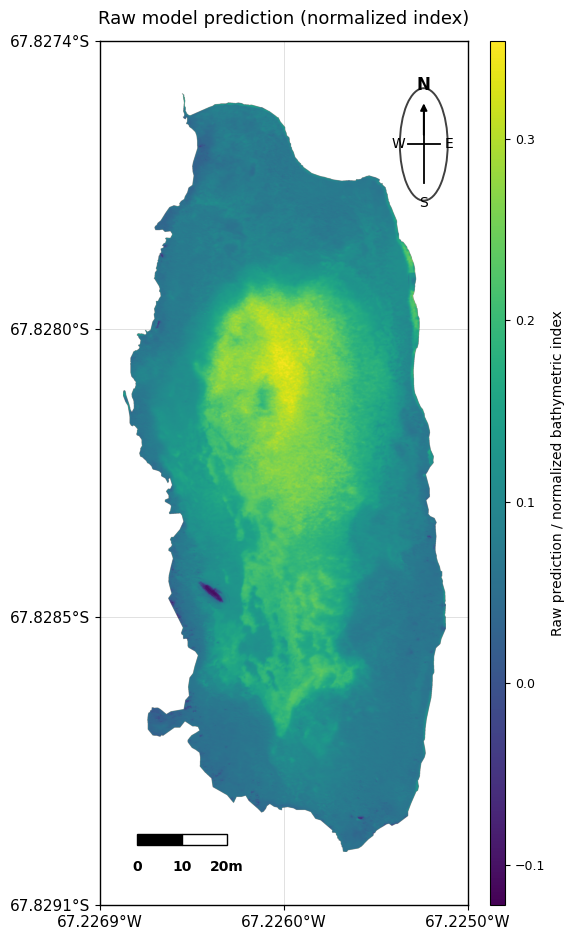

In [ ]:
# ============================================================
# 14A - Raw predicted map visualization
# ============================================================


def plot_raw_prediction_professional(
    raw_tif,
    out_png=None,
    title="Raw model prediction (normalized index)",
    cmap="viridis"
):
    arr, bounds, crs, extent = read_raster_for_plot(raw_tif)
    pb = padded_bounds(bounds, pad_frac=0.07)

    fig, ax = plt.subplots(figsize=(7.2, 9.5))

    im = ax.imshow(
        arr,
        extent=extent,
        origin="upper",
        cmap=cmap,
        zorder=2
    )

    ax.set_xlim(pb["left"], pb["right"])
    ax.set_ylim(pb["bottom"], pb["top"])

    set_sw_ticks_with_padding(ax, crs, pb, nx=3, ny=4, decimals=4)

    ax.grid(True, color="gray", alpha=0.28, linewidth=0.6, zorder=1)

    add_north_arrow_clean(ax, x=0.88, y=0.88, size=0.065)
    add_scale_bar_clean(ax, pb, length_m=20, location=(0.10, 0.07))

    ax.set_title(title, fontsize=13, pad=12)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4.2%", pad=0.22)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Raw prediction / normalized bathymetric index", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
        print("Saved:", out_png)

    plt.show()

plot_raw_prediction_professional(
    RAW_TIF,
    out_png=OUT_DIR / "prediction_raw_professional_SW.png"
)

Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_raw_with_gpr_professional_SW.png


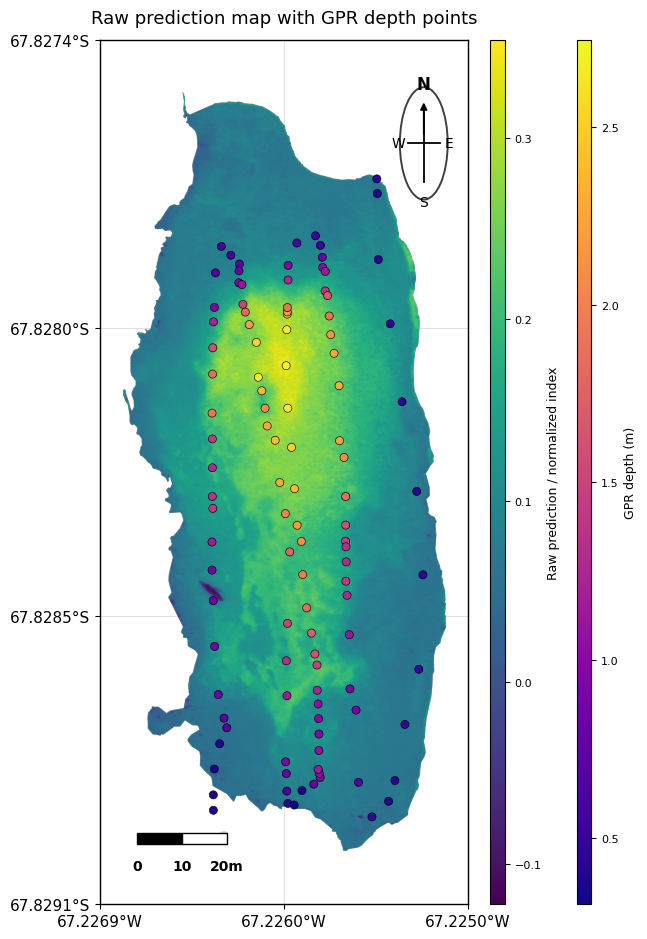

In [ ]:
# ============================================================
# 14B - Raw predicted map + GPR point overlay
# ============================================================


def plot_raw_prediction_with_gpr_professional(
    raw_tif,
    gpr_proj,
    out_png=None,
    title="Raw prediction map with GPR depth points",
    cmap_raw="viridis",
    cmap_gpr="plasma"
):
    arr, bounds, crs, extent = read_raster_for_plot(raw_tif)
    pb = padded_bounds(bounds, pad_frac=0.07)

    fig, ax = plt.subplots(figsize=(7.6, 9.5))

    im = ax.imshow(
        arr,
        extent=extent,
        origin="upper",
        cmap=cmap_raw,
        zorder=2
    )

    sc = ax.scatter(
        gpr_proj["x_proj"],
        gpr_proj["y_proj"],
        c=gpr_proj["Depth [m]"],
        s=34,
        edgecolors="black",
        linewidths=0.45,
        cmap=cmap_gpr,
        zorder=5
    )

    ax.set_xlim(pb["left"], pb["right"])
    ax.set_ylim(pb["bottom"], pb["top"])

    set_sw_ticks_with_padding(ax, crs, pb, nx=3, ny=4, decimals=4)

    ax.grid(True, color="gray", alpha=0.28, linewidth=0.6, zorder=1)

    add_north_arrow_clean(ax, x=0.88, y=0.88, size=0.065)
    add_scale_bar_clean(ax, pb, length_m=20, location=(0.10, 0.07))

    ax.set_title(title, fontsize=13, pad=12)

    divider = make_axes_locatable(ax)

    cax1 = divider.append_axes("right", size="4.0%", pad=0.22)
    cbar1 = fig.colorbar(im, cax=cax1)
    cbar1.set_label("Raw prediction / normalized index", fontsize=9)
    cbar1.ax.tick_params(labelsize=8)

    cax2 = divider.append_axes("right", size="4.0%", pad=0.72)
    cbar2 = fig.colorbar(sc, cax=cax2)
    cbar2.set_label("GPR depth (m)", fontsize=9)
    cbar2.ax.tick_params(labelsize=8)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
        print("Saved:", out_png)

    plt.show()

plot_raw_prediction_with_gpr_professional(
    RAW_TIF,
    gpr_proj,
    out_png=OUT_DIR / "prediction_raw_with_gpr_professional_SW.png"
)

Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_calibrated_depth_professional_SW.png


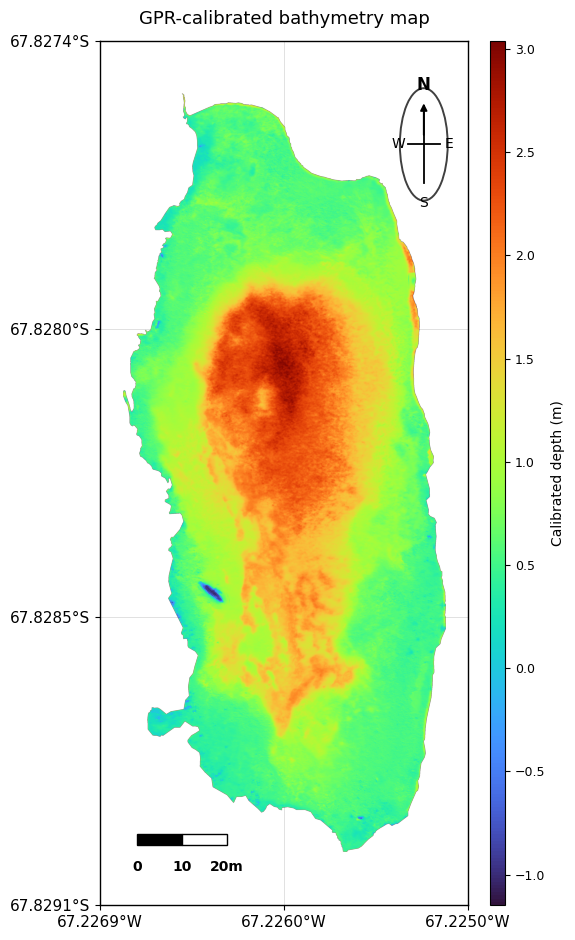

In [ ]:
# ============================================================
# Professional calibrated bathymetry map
# ============================================================

def plot_calibrated_bathymetry_professional(
    cal_tif,
    out_png=None,
    title="GPR-calibrated bathymetry map",
    cmap="turbo"
):
    arr, bounds, crs, extent = read_raster_for_plot(cal_tif)
    pb = padded_bounds(bounds, pad_frac=0.07)

    fig, ax = plt.subplots(figsize=(7.2, 9.5))

    im = ax.imshow(
        arr,
        extent=extent,
        origin="upper",
        cmap=cmap,
        zorder=2
    )

    ax.set_xlim(pb["left"], pb["right"])
    ax.set_ylim(pb["bottom"], pb["top"])

    set_sw_ticks_with_padding(ax, crs, pb, nx=3, ny=4, decimals=4)

    ax.grid(True, color="gray", alpha=0.28, linewidth=0.6, zorder=1)

    add_north_arrow_clean(ax, x=0.88, y=0.88, size=0.065)
    add_scale_bar_clean(ax, pb, length_m=20, location=(0.10, 0.07))

    ax.set_title(title, fontsize=13, pad=12)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4.2%", pad=0.22)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Calibrated depth (m)", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
        print("Saved:", out_png)

    plt.show()

plot_calibrated_bathymetry_professional(
    CAL_TIF,
    out_png=OUT_DIR / "prediction_calibrated_depth_professional_SW.png"
)

In [ ]:
# ============================================================
# 15 - Raw / inverse / calibrated evaluation
# ============================================================
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[ok]
    y_pred = y_pred[ok]

    if len(y_true) < 3:
        raise ValueError("Metrik için yeterli valid örnek yok.")

    err = y_pred - y_true
    pr = pearsonr(y_true, y_pred)[0] if np.std(y_pred) > 0 and np.std(y_true) > 0 else np.nan
    sr = spearmanr(y_true, y_pred)[0] if np.std(y_pred) > 0 and np.std(y_true) > 0 else np.nan
    return {
        "n": len(y_true),
        "Pearson R": float(pr),
        "Spearman R": float(sr),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R²": float(r2_score(y_true, y_pred)),
        "Bias": float(np.mean(err)),
    }

def fit_linear_calibration(x, y):
    x = np.asarray(x, dtype=np.float64).reshape(-1,1)
    y = np.asarray(y, dtype=np.float64)
    model = LinearRegression()
    model.fit(x, y)
    pred = model.predict(x)
    return model, pred

valid = sampled_raw[sampled_raw["valid_sample"]].copy()
y_true_m = valid["Depth [m]"].to_numpy(dtype=float)
raw_index = valid["pred_sample"].to_numpy(dtype=float)

raw_as_meter = raw_index
raw_scaled_m = label_to_depth_m(raw_index, norm_param_depth)

raw01, _, _ = normalize_01(raw_index)
inv01 = 1.0 - raw01
inverse_scaled_m = inv01 * depth_scale_m

cal_raw_model, cal_raw_pred = fit_linear_calibration(raw_index, y_true_m)
cal_inv_model, cal_inv_pred = fit_linear_calibration(inv01, y_true_m)

rows = []
candidates = {
    "raw_index_as_meter_CHECK_ONLY": raw_as_meter,
    "raw_scaled_by_label_convention_m": raw_scaled_m,
    "inverse_01_scaled_m": inverse_scaled_m,
    "linear_calibrated_raw_m": cal_raw_pred,
    "linear_calibrated_inverse_m": cal_inv_pred,
}

for name, pred in candidates.items():
    met = compute_metrics(y_true_m, pred)
    met["case"] = name
    rows.append(met)

metrics_df = pd.DataFrame(rows)[["case","n","Pearson R","Spearman R","MAE","RMSE","R²","Bias"]]
display(metrics_df)

print("Raw calibration: depth_m = {:.4f} * raw + {:.4f}".format(float(cal_raw_model.coef_[0]), float(cal_raw_model.intercept_)))
print("Inverse calibration: depth_m = {:.4f} * inv01 + {:.4f}".format(float(cal_inv_model.coef_[0]), float(cal_inv_model.intercept_)))

metrics_df.to_csv(OUT_DIR / "gpr_evaluation_raw_inverse_calibrated.csv", index=False)
print("Saved:", OUT_DIR / "gpr_evaluation_raw_inverse_calibrated.csv")


,case,n,Pearson R,Spearman R,MAE,RMSE,R²,Bias
0,raw_index_as_meter_CHECK_ONLY,109,0.943351,0.936368,1.144449,1.302503,-2.549516,-1.144449e+00
1,raw_scaled_by_label_convention_m,109,0.943351,0.936368,0.426059,0.503171,0.470285,4.169940e-01
2,inverse_01_scaled_m,109,-0.943351,-0.936368,5.816350,6.637027,-91.163435,5.683693e+00
3,linear_calibrated_raw_m,109,0.943351,0.936368,0.172006,0.229385,0.889912,-1.884323e-16
4,linear_calibrated_inverse_m,109,0.943351,0.936368,0.172006,0.229385,0.889912,-3.646421e-16


Raw calibration: depth_m = 8.7968 * raw + -0.0730
Inverse calibration: depth_m = -2.5924 * inv01 + 2.9466
Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/gpr_evaluation_raw_inverse_calibrated.csv


In [ ]:
# ============================================================
# 15A - Cross-validation calibration
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) < 2:
        return {
            "n": len(y_true),
            "Pearson R": np.nan,
            "Spearman R": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R²": np.nan,
            "Bias": np.nan
        }

    return {
        "n": len(y_true),
        "Pearson R": pearsonr(y_true, y_pred)[0],
        "Spearman R": spearmanr(y_true, y_pred)[0],
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred),
        "Bias": np.mean(y_pred - y_true)
    }

def fit_linear_calibration(x, y):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float)

    model = LinearRegression()
    model.fit(x, y)

    return model

def apply_linear_calibration(model, x):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    return model.predict(x)

def cross_validated_linear_calibration(df, pred_col="pred_sample", target_col="Depth [m]", mode="kfold", n_splits=5):
    valid = df.copy()
    valid = valid[np.isfinite(valid[pred_col]) & np.isfinite(valid[target_col])]

    x = valid[pred_col].to_numpy(dtype=float)
    y = valid[target_col].to_numpy(dtype=float)

    y_pred_cv = np.full(len(valid), np.nan, dtype=float)

    if mode == "loocv":
        splitter = LeaveOneOut()
    elif mode == "kfold":
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    else:
        raise ValueError("mode must be 'loocv' or 'kfold'")

    coefs = []
    intercepts = []

    for train_idx, test_idx in splitter.split(x):
        model = fit_linear_calibration(x[train_idx], y[train_idx])
        y_pred_cv[test_idx] = apply_linear_calibration(model, x[test_idx])

        coefs.append(float(model.coef_[0]))
        intercepts.append(float(model.intercept_))

    metrics = compute_metrics(y, y_pred_cv)

    out = valid.copy()
    out["pred_cv_calibrated_m"] = y_pred_cv
    out["cv_residual_m"] = out["pred_cv_calibrated_m"] - out[target_col]

    summary = {
        "case": f"CV_linear_calibrated_raw_{mode}",
        **metrics,
        "coef_mean": float(np.mean(coefs)),
        "coef_std": float(np.std(coefs)),
        "intercept_mean": float(np.mean(intercepts)),
        "intercept_std": float(np.std(intercepts))
    }

    return out, summary

# Use only valid GPR samples
valid_gpr = sampled_raw.copy()
valid_gpr = valid_gpr[valid_gpr["valid_sample"] == True].copy()

# LOOCV
cv_loocv_df, cv_loocv_summary = cross_validated_linear_calibration(
    valid_gpr,
    pred_col="pred_sample",
    target_col="Depth [m]",
    mode="loocv"
)

# 5-fold CV
cv_5fold_df, cv_5fold_summary = cross_validated_linear_calibration(
    valid_gpr,
    pred_col="pred_sample",
    target_col="Depth [m]",
    mode="kfold",
    n_splits=5
)

cv_summary_df = pd.DataFrame([cv_loocv_summary, cv_5fold_summary])

display(cv_summary_df)

cv_loocv_df.to_csv(OUT_DIR / "gpr_cv_loocv_calibrated_raw.csv", index=False)
cv_5fold_df.to_csv(OUT_DIR / "gpr_cv_5fold_calibrated_raw.csv", index=False)
cv_summary_df.to_csv(OUT_DIR / "gpr_cv_calibration_summary.csv", index=False)

print("Saved CV outputs to:", OUT_DIR)

,case,n,Pearson R,Spearman R,MAE,RMSE,R²,Bias,coef_mean,coef_std,intercept_mean,intercept_std
0,CV_linear_calibrated_raw_loocv,109,0.941327,0.934579,0.175102,0.233333,0.886089,0.000095,8.796884,0.026588,-0.072989,0.004094
1,CV_linear_calibrated_raw_kfold,109,0.941755,0.935553,0.173290,0.232551,0.886851,0.002679,8.804801,0.148573,-0.073690,0.021339


Saved CV outputs to: /content/drive/MyDrive/MagicBathyNet/debug_outputs


In [ ]:
# ============================================================
# 15B - Combine in-sample and CV metric summaries
# ============================================================

# Existing metrics_df from previous cell should contain in-sample cases.
# If metrics_df exists, combine it with CV summary.

metrics_df_labeled = metrics_df.copy()
metrics_df_labeled["evaluation_type"] = "in_sample_or_check"

cv_summary_labeled = cv_summary_df.copy()
cv_summary_labeled["evaluation_type"] = "cross_validated"

# Keep only common/report columns
report_cols = [
    "evaluation_type",
    "case",
    "n",
    "Pearson R",
    "Spearman R",
    "MAE",
    "RMSE",
    "R²",
    "Bias"
]

final_metric_report = pd.concat(
    [
        metrics_df_labeled[report_cols],
        cv_summary_labeled[report_cols]
    ],
    ignore_index=True
)

display(final_metric_report)

final_metric_report.to_csv(
    OUT_DIR / "final_metric_report_insample_and_cv.csv",
    index=False
)

print("Saved:", OUT_DIR / "final_metric_report_insample_and_cv.csv")

,evaluation_type,case,n,Pearson R,Spearman R,MAE,RMSE,R²,Bias
0,in_sample_or_check,raw_index_as_meter_CHECK_ONLY,109,0.943351,0.936368,1.144449,1.302503,-2.549516,-1.144449e+00
1,in_sample_or_check,raw_scaled_by_label_convention_m,109,0.943351,0.936368,0.426059,0.503171,0.470285,4.169940e-01
2,in_sample_or_check,inverse_01_scaled_m,109,-0.943351,-0.936368,5.816350,6.637027,-91.163435,5.683693e+00
3,in_sample_or_check,linear_calibrated_raw_m,109,0.943351,0.936368,0.172006,0.229385,0.889912,-1.884323e-16
4,in_sample_or_check,linear_calibrated_inverse_m,109,0.943351,0.936368,0.172006,0.229385,0.889912,-3.646421e-16
5,cross_validated,CV_linear_calibrated_raw_loocv,109,0.941327,0.934579,0.175102,0.233333,0.886089,9.469436e-05
6,cross_validated,CV_linear_calibrated_raw_kfold,109,0.941755,0.935553,0.173290,0.232551,0.886851,2.679228e-03


Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/final_metric_report_insample_and_cv.csv


In [ ]:
# ============================================================
# 16A - Kalibre edilmiş GeoTIFF üretimi
# ============================================================
CAL_RAW_TIF = OUT_DIR / "prediction_calibrated_raw_m.tif"
CAL_INV_TIF = OUT_DIR / "prediction_calibrated_inverse_m.tif"

def apply_calibration_to_raster(in_tif, out_tif, mode, cal_model=None, norm_param_depth=-11.0):
    with rasterio.open(in_tif) as src:
        arr = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata = src.nodata
        valid = np.isfinite(arr)
        if nodata is not None:
            valid &= arr != nodata
        valid &= arr != 0

    out = np.full_like(arr, 0, dtype=np.float32)

    if mode == "raw_label_to_meter":
        out[valid] = label_to_depth_m(arr[valid], norm_param_depth)
    elif mode == "linear_raw":
        out[valid] = cal_model.predict(arr[valid].reshape(-1,1)).astype(np.float32)
    elif mode == "linear_inverse":
        arr01, mn, mx = normalize_01(arr, valid)
        inv = 1.0 - arr01
        out[valid] = cal_model.predict(inv[valid].reshape(-1,1)).astype(np.float32)
    else:
        raise ValueError(mode)

    profile.update(dtype="float32", count=1, nodata=0.0, compress="lzw")
    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(out.astype(np.float32), 1)

    print("Saved:", out_tif)

apply_calibration_to_raster(RAW_TIF, CAL_RAW_TIF, "linear_raw", cal_model=cal_raw_model)
apply_calibration_to_raster(RAW_TIF, CAL_INV_TIF, "linear_inverse", cal_model=cal_inv_model)


Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_calibrated_raw_m.tif


Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_calibrated_inverse_m.tif


In [ ]:
# ============================================================
# FIX - Define write_calibrated_geotiff function
# ============================================================

import numpy as np
import rasterio
from pathlib import Path

def write_calibrated_geotiff(raw_tif, out_tif, calibration_model):
    raw_tif = Path(raw_tif)
    out_tif = Path(out_tif)

    if not raw_tif.exists():
        raise FileNotFoundError(f"Raw prediction GeoTIFF not found: {raw_tif}")

    with rasterio.open(raw_tif) as src:
        raw = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata = src.nodata
        crs = src.crs
        transform = src.transform

    raw_flat = raw.reshape(-1)

    valid = np.isfinite(raw_flat)

    if nodata is not None:
        valid &= raw_flat != nodata

    calibrated_flat = np.full(raw_flat.shape, np.nan, dtype=np.float32)

    calibrated_flat[valid] = calibration_model.predict(
        raw_flat[valid].reshape(-1, 1)
    ).astype(np.float32)

    calibrated = calibrated_flat.reshape(raw.shape)

    out_nodata = -9999.0
    calibrated_out = calibrated.copy()
    calibrated_out[~np.isfinite(calibrated_out)] = out_nodata

    profile.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=out_nodata,
        compress="lzw",
        crs=crs,
        transform=transform
    )

    # Colab/GDAL block-size warninglarını azaltmak için inherited tile ayarlarını temizliyoruz.
    profile.pop("blockxsize", None)
    profile.pop("blockysize", None)
    profile.pop("tiled", None)
    profile.pop("interleave", None)

    out_tif.parent.mkdir(parents=True, exist_ok=True)

    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(calibrated_out.astype(np.float32), 1)

    print("Saved calibrated GeoTIFF:", out_tif)
    print("CRS preserved:", crs)
    print("Transform preserved:", transform)
    print("Calibration equation:")
    print(
        f"depth_m = {float(calibration_model.coef_[0]):.6f} * raw "
        f"+ {float(calibration_model.intercept_):.6f}"
    )

    print("Output min/max excluding nodata:")
    valid_out = calibrated_out[calibrated_out != out_nodata]
    print(float(np.nanmin(valid_out)), float(np.nanmax(valid_out)))

    return out_tif

In [ ]:
CAL_TIF = write_calibrated_geotiff(
    RAW_TIF,
    CAL_TIF,
    final_raw_cal_model
)

Saved calibrated GeoTIFF: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_linear_calibrated_raw_depth_m.tif
CRS preserved: EPSG:32719
Transform preserved: | 0.04, 0.00, 574667.78|
| 0.00,-0.04, 2475298.14|
| 0.00, 0.00, 1.00|
Calibration equation:
depth_m = 8.796840 * raw + -0.072983
Output min/max excluding nodata:
-1.1484543085098267 3.0400233268737793


Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/prediction_linear_calibrated_raw_depth_m_map.png


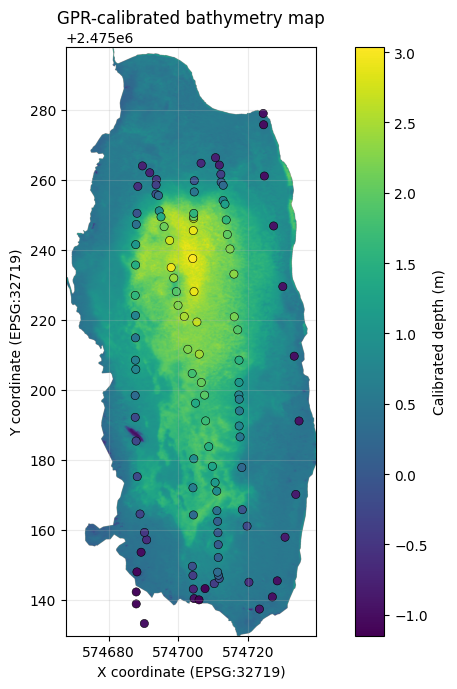

In [ ]:
# ============================================================
# 16B - Final calibrated bathymetry map visualization
# ============================================================

def plot_calibrated_depth_map(cal_tif, gpr_proj=None, out_png=None):
    with rasterio.open(cal_tif) as src:
        depth = src.read(1).astype(np.float32)
        nodata = src.nodata
        bounds = src.bounds
        crs = src.crs

    depth_plot = depth.copy()

    if nodata is not None:
        depth_plot[depth_plot == nodata] = np.nan

    depth_plot[~np.isfinite(depth_plot)] = np.nan

    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    plt.figure(figsize=(8, 7))
    im = plt.imshow(
        depth_plot,
        extent=extent,
        origin="upper"
    )

    plt.colorbar(im, label="Calibrated depth (m)")

    if gpr_proj is not None:
        plt.scatter(
            gpr_proj["x_proj"],
            gpr_proj["y_proj"],
            c=gpr_proj["Depth [m]"],
            s=35,
            edgecolors="black",
            linewidths=0.4
        )

    plt.xlabel(f"X coordinate ({crs})")
    plt.ylabel(f"Y coordinate ({crs})")
    plt.title("GPR-calibrated bathymetry map")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print("Saved:", out_png)

    plt.show()

plot_calibrated_depth_map(
    CAL_TIF,
    gpr_proj=gpr_proj,
    out_png=OUT_DIR / "prediction_linear_calibrated_raw_depth_m_map.png"
)

Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/scatter_observed_vs_predicted_insample_calibrated.png


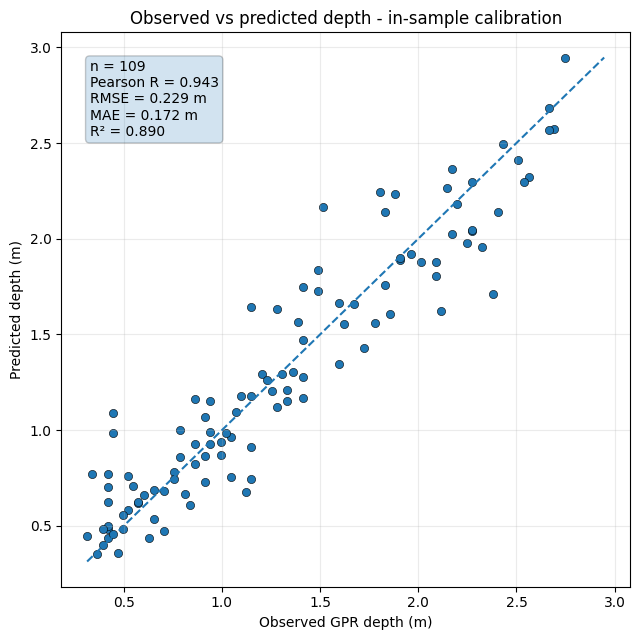

Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/scatter_observed_vs_predicted_loocv.png


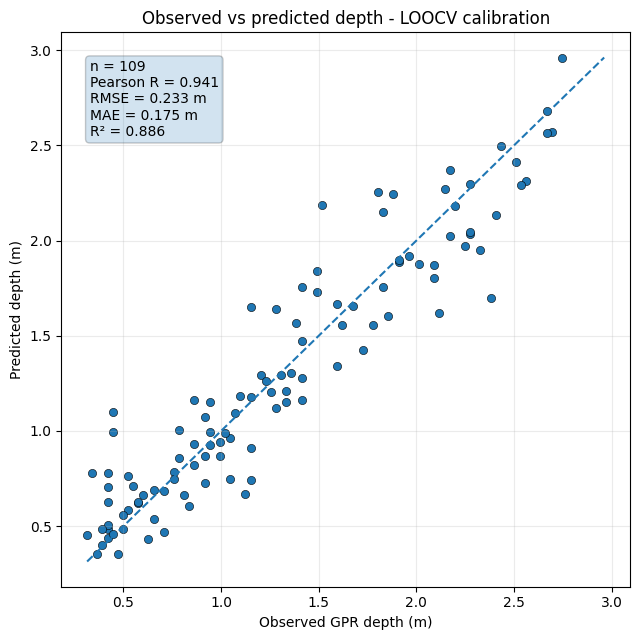

Saved: /content/drive/MyDrive/MagicBathyNet/debug_outputs/scatter_observed_vs_predicted_5fold.png


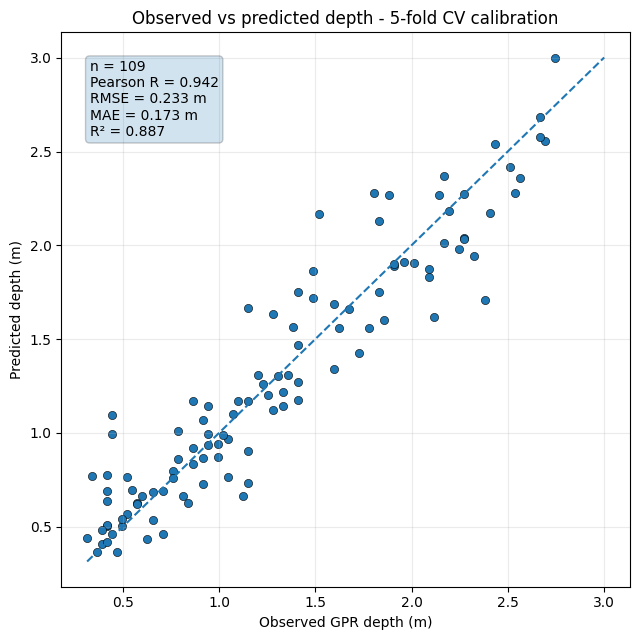

In [ ]:
# ============================================================
# 17 - Observed vs predicted scatter plot
# ============================================================

def plot_observed_vs_predicted(df, pred_col, title, out_png=None):
    y_true = df["Depth [m]"].to_numpy(dtype=float)
    y_pred = df[pred_col].to_numpy(dtype=float)

    metrics = compute_metrics(y_true, y_pred)

    min_val = np.nanmin([np.nanmin(y_true), np.nanmin(y_pred)])
    max_val = np.nanmax([np.nanmax(y_true), np.nanmax(y_pred)])

    plt.figure(figsize=(6.5, 6.5))
    plt.scatter(y_true, y_pred, s=35, edgecolors="black", linewidths=0.4)
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Observed GPR depth (m)")
    plt.ylabel("Predicted depth (m)")
    plt.title(title)

    text = (
        f"n = {metrics['n']}\n"
        f"Pearson R = {metrics['Pearson R']:.3f}\n"
        f"RMSE = {metrics['RMSE']:.3f} m\n"
        f"MAE = {metrics['MAE']:.3f} m\n"
        f"R² = {metrics['R²']:.3f}"
    )

    plt.text(
        0.05,
        0.95,
        text,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.2)
    )

    plt.grid(alpha=0.25)
    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print("Saved:", out_png)

    plt.show()

# In-sample calibrated predictions
valid_gpr["pred_insample_calibrated_m"] = final_raw_cal_model.predict(
    valid_gpr["pred_sample"].to_numpy(dtype=float).reshape(-1, 1)
)

plot_observed_vs_predicted(
    valid_gpr,
    pred_col="pred_insample_calibrated_m",
    title="Observed vs predicted depth - in-sample calibration",
    out_png=OUT_DIR / "scatter_observed_vs_predicted_insample_calibrated.png"
)

plot_observed_vs_predicted(
    cv_loocv_df,
    pred_col="pred_cv_calibrated_m",
    title="Observed vs predicted depth - LOOCV calibration",
    out_png=OUT_DIR / "scatter_observed_vs_predicted_loocv.png"
)

plot_observed_vs_predicted(
    cv_5fold_df,
    pred_col="pred_cv_calibrated_m",
    title="Observed vs predicted depth - 5-fold CV calibration",
    out_png=OUT_DIR / "scatter_observed_vs_predicted_5fold.png"
)

# Tez/savunma yorum taslağı

Model ham çıktısı mutlak metre cinsinden doğrudan derinlik üretmemiştir. Çıktı, öncelikle göreli batimetrik indeks olarak değerlendirilmiştir. GPR ölçümleriyle yapılan noktasal karşılaştırmada ham çıktı ile fiziksel derinlik arasında ters yönlü bir ilişki gözlenmesi durumunda, bu davranış model çıktısındaki derinlik polaritesinin çalışma alanındaki in-situ derinlik konvansiyonu ile uyumsuz olabileceğini göstermektedir. Bu nedenle ham çıktı üzerinde polarity correction uygulanmış, ardından GPR/in-situ ölçümleri kullanılarak regresyon tabanlı kalibrasyon yapılmış ve çıktı metre cinsinden batimetrik derinlik haritasına dönüştürülmüştür.

Bu sonuçlar iki ayrı performans boyutunda değerlendirilmelidir. İlk olarak model, göl içi sığ-derin geçişleri ve genel batimetrik morfolojiyi görsel olarak temsil edebilmiştir. İkinci olarak, mutlak metrik derinlik ölçeği doğrudan model çıktısından güvenilir biçimde elde edilememiş; saha ölçümlerine dayalı kalibrasyon ihtiyacı ortaya çıkmıştır. Bu fark, optik su kolonu özellikleri, taban yansıtımı, bulanıklık, sunglint, radyometrik farklılıklar ve eğitim verisi ile çalışma alanı arasındaki domain shift etkileriyle açıklanabilir. Eğer eğitim ve test ayrımı patch tabanlı yapılmışsa, aynı sahneden gelen komşu örneklerin farklı setlere dağılması spatial leakage riski oluşturabilir. Bu nedenle sonuçlar raporlanırken random patch split yerine spatial split veya spatial block cross-validation ile doğrulama yapılması önerilir.
